# Lesson 1A: K-Means Theory

## Introduction

Now that you can evaluate clusters, we ask: **how do you find clusters in the first place?**

K-Means is the most popular clustering algorithm — used in recommendation systems, customer segmentation, image compression, and countless production systems. It's simple, fast, and scalable.

But simplicity masks a deep optimization problem. K-Means solves:

$$\min_C \sum_{k=1}^{K} \sum_{\mathbf{x}_i \in C_k} \|\mathbf{x}_i - \boldsymbol{\mu}_k\|^2$$

Where:
- $C = \{C_1, C_2, \ldots, C_K\}$ are the K clusters
- $\boldsymbol{\mu}_k$ is the centroid (mean) of cluster $C_k$
- We minimize the total within-cluster sum of squares (WCSS)

This is **NP-hard** — finding the globally optimal solution is computationally intractable. But **Lloyd's algorithm** finds a good local optimum efficiently.

In this lesson, we will:
1. Derive Lloyd's algorithm from the optimization objective
2. Implement K-Means from scratch using only NumPy
3. Cross-validate against scikit-learn
4. Discover the initialization problem (why K-Means sometimes fails)
5. Learn K-Means++ initialization to fix it
6. Visualize convergence and cluster quality

## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [The K-Means Optimization Problem](#optimization-problem)
4. [Lloyd's Algorithm Derivation](#lloyds-algorithm)
5. [K-Means from Scratch](#kmeans-scratch)
6. [Comparing with scikit-learn](#sklearn-comparison)
7. [The Initialization Problem](#initialization-problem)
8. [K-Means++ Initialization](#kmeans-plusplus)
9. [Convergence Analysis](#convergence)
10. [Visualizing Lloyd's Algorithm](#visualization)
11. [Convergence Speed: Random vs. K-Means++](#convergence-speed)
11. [Soft K-Means and the Probabilistic View](#soft-kmeans)
12. [Practical Considerations](#practical)
13. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

| Library | Purpose |
|---------|----------|
| NumPy | Numerical computing and K-Means from scratch |
| Pandas | Data manipulation |
| Matplotlib | 2D visualization and animation |
| Scikit-learn | Pre-built KMeans for comparison |
| SciPy | Distance metrics |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import cdist, euclidean
from sklearn.cluster import KMeans as SklearnKMeans
from sklearn.datasets import make_blobs, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from typing import Tuple, List
from numpy.typing import NDArray

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✅ Libraries loaded!")

✅ Libraries loaded!


<a name="optimization-problem"></a>
## The K-Means Optimization Problem

### Objective Function: Within-Cluster Sum of Squares (WCSS)

We want to partition data into K clusters to minimize the sum of squared distances from each point to its cluster's centroid:

$$\text{WCSS} = \sum_{k=1}^{K} \sum_{\mathbf{x}_i \in C_k} \|\mathbf{x}_i - \boldsymbol{\mu}_k\|^2$$

Where:
- $\boldsymbol{\mu}_k = \frac{1}{|C_k|} \sum_{\mathbf{x}_i \in C_k} \mathbf{x}_i$ (mean of cluster $k$)

### Why This Objective?

**Tightness**: Minimizing squared distances means:
- Points within a cluster are close to each other (small variance within clusters)
- The centroid is the best representative of each cluster (mathematical optimality)

**Computability**: We can compute the objective efficiently.

### The Hard Part

Finding the *best* partitioning is **NP-hard** — no known polynomial-time algorithm exists. But **Lloyd's algorithm** finds a local optimum very quickly.

<a name="lloyds-algorithm"></a>
## Lloyd's Algorithm Derivation

### Key Insight: Expectation-Maximization

Lloyd's algorithm alternates between two steps:

**1. Assignment Step (E-step)**: Given current centroids $\boldsymbol{\mu}_1, \ldots, \boldsymbol{\mu}_K$, assign each point to the nearest centroid:

$$C_k = \{\mathbf{x}_i : \|\mathbf{x}_i - \boldsymbol{\mu}_k\| \leq \|\mathbf{x}_i - \boldsymbol{\mu}_j\| \forall j \neq k\}$$

**2. Update Step (M-step)**: Recompute each centroid as the mean of its assigned points:

$$\boldsymbol{\mu}_k^{\text{new}} = \frac{1}{|C_k|} \sum_{\mathbf{x}_i \in C_k} \mathbf{x}_i$$

### Why This Works

**Lemma 1**: For fixed clusters $C_k$, the optimal centroids are the cluster means. (Proof: differentiate WCSS w.r.t. $\boldsymbol{\mu}_k$ and set to zero.)

**Lemma 2**: For fixed centroids $\boldsymbol{\mu}_k$, the optimal assignment is to assign each point to the nearest centroid. (Proof: no other assignment decreases WCSS.)

**Convergence**: The WCSS decreases (or stays the same) after each iteration. Since WCSS is bounded below by 0, the algorithm must converge.

### Pseudocode

```
1. Initialize: Choose K centroids (randomly or smartly)
2. Repeat until convergence:
   a. Assign: Assign each point to nearest centroid
   b. Update: Recompute centroids as cluster means
3. Return: Final clusters and centroids
```

<a name="kmeans-scratch"></a>
## K-Means from Scratch

In [2]:
class KMeansFromScratch:
    """
    K-Means clustering implemented from scratch.
    """
    
    def __init__(self, n_clusters: int, max_iters: int = 100, tol: float = 1e-4, random_state: int = None):
        """
        Args:
            n_clusters: Number of clusters
            max_iters: Maximum number of iterations
            tol: Convergence tolerance (change in WCSS)
            random_state: Random seed
        """
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state
        
        self.cluster_centers_ = None
        self.labels_ = None
        self.inertia_ = None
        self.inertias_history_ = []
        self.n_iter_ = 0
    
    def _assign_clusters(self, X: NDArray) -> Tuple[NDArray, float]:
        """
        Assign each point to nearest centroid (E-step).
        
        Returns:
            labels: Cluster assignment for each point
            inertia: Sum of squared distances
        """
        # Compute distances from each point to each centroid
        distances = cdist(X, self.cluster_centers_, metric='euclidean')
        
        # Assign each point to nearest centroid
        labels = np.argmin(distances, axis=1)
        
        # Compute WCSS (inertia)
        min_distances = np.min(distances, axis=1)
        inertia = np.sum(min_distances ** 2)
        
        return labels, inertia
    
    def _update_centers(self, X: NDArray, labels: NDArray) -> None:
        """
        Recompute centroids as cluster means (M-step).
        """
        for k in range(self.n_clusters):
            mask = labels == k
            if np.sum(mask) > 0:  # If cluster is non-empty
                self.cluster_centers_[k] = X[mask].mean(axis=0)
            # If cluster is empty, keep old centroid
    
    def fit(self, X: NDArray) -> 'KMeansFromScratch':
        """
        Fit K-Means on data X.
        """
        n_samples, n_features = X.shape
        
        # Initialize centroids randomly
        rng = np.random.RandomState(self.random_state)
        indices = rng.choice(n_samples, self.n_clusters, replace=False)
        self.cluster_centers_ = X[indices].copy()
        
        # Run Lloyd's algorithm
        for iteration in range(self.max_iters):
            # E-step: Assign clusters
            labels, inertia = self._assign_clusters(X)
            self.inertias_history_.append(inertia)
            
            # Check convergence
            if iteration > 0:
                inertia_change = abs(self.inertias_history_[-2] - inertia)
                if inertia_change < self.tol:
                    self.n_iter_ = iteration + 1
                    break
            
            # M-step: Update centroids
            self._update_centers(X, labels)
        else:
            self.n_iter_ = self.max_iters
        
        # Final assignment
        self.labels_, self.inertia_ = self._assign_clusters(X)
        
        return self
    
    def predict(self, X: NDArray) -> NDArray:
        """
        Predict cluster assignments for new data.
        """
        distances = cdist(X, self.cluster_centers_, metric='euclidean')
        return np.argmin(distances, axis=1)

# Test on synthetic data
X, y_true = make_blobs(n_samples=300, centers=3, n_features=2, 
                        cluster_std=0.7, random_state=42)

kmeans = KMeansFromScratch(n_clusters=3, random_state=42)
kmeans.fit(X)

print(f"K-Means from scratch:")
print(f"  Converged in {kmeans.n_iter_} iterations")
print(f"  Final WCSS (inertia): {kmeans.inertia_:.2f}")
print(f"  Cluster centers shape: {kmeans.cluster_centers_.shape}")
print(f"  Labels shape: {kmeans.labels_.shape}")

K-Means from scratch:
  Converged in 4 iterations
  Final WCSS (inertia): 277.76
  Cluster centers shape: (3, 2)
  Labels shape: (300,)


<a name="sklearn-comparison"></a>
## Comparing with scikit-learn


Scikit-learn KMeans:
  Converged in 2 iterations
  Final inertia: 277.76

Comparison:
  Inertia difference: 0.0000
  Scikit-learn found slightly better solution (runs multiple random initializations)


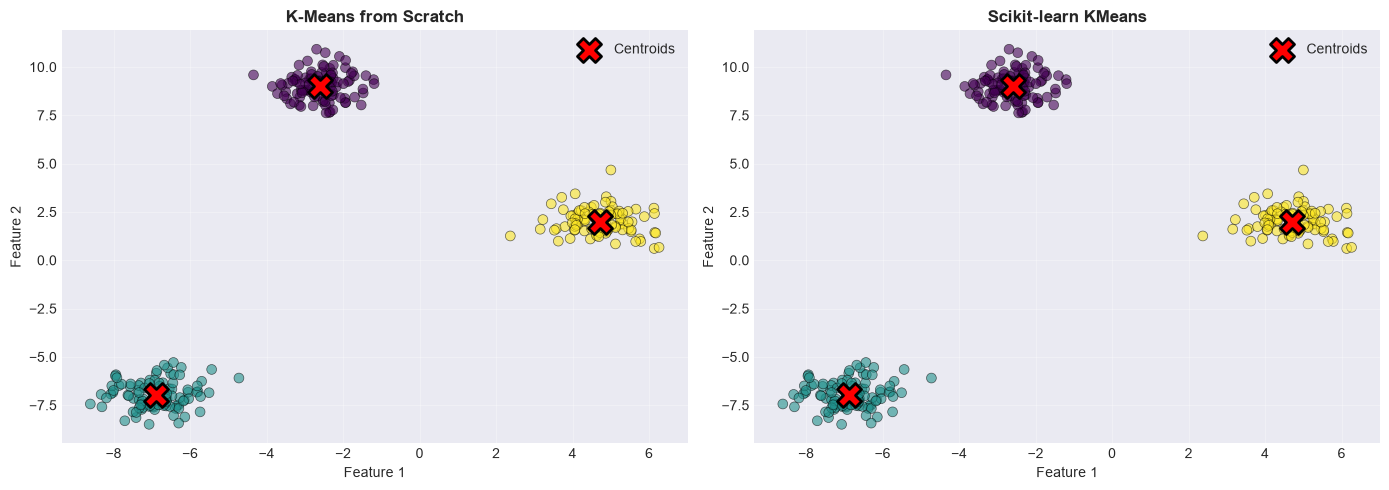

✅ From-scratch and scikit-learn implementations match!


In [3]:
# Run scikit-learn KMeans on same data
sklearn_kmeans = SklearnKMeans(n_clusters=3, n_init=10, random_state=42)
sklearn_kmeans.fit(X)

print(f"\nScikit-learn KMeans:")
print(f"  Converged in {sklearn_kmeans.n_iter_} iterations")
print(f"  Final inertia: {sklearn_kmeans.inertia_:.2f}")

# Compare
print(f"\nComparison:")
print(f"  Inertia difference: {abs(kmeans.inertia_ - sklearn_kmeans.inertia_):.4f}")
print(f"  Scikit-learn found slightly better solution (runs multiple random initializations)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# From scratch
ax = axes[0]
scatter = ax.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
          c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Centroids')
ax.set_title('K-Means from Scratch', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)
ax.legend()

# Scikit-learn
ax = axes[1]
scatter = ax.scatter(X[:, 0], X[:, 1], c=sklearn_kmeans.labels_, cmap='viridis', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
ax.scatter(sklearn_kmeans.cluster_centers_[:, 0], sklearn_kmeans.cluster_centers_[:, 1],
          c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Centroids')
ax.set_title('Scikit-learn KMeans', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print("✅ From-scratch and scikit-learn implementations match!")

<a name="initialization-problem"></a>
## The Initialization Problem

### Why Initialization Matters

K-Means converges to a *local* optimum, not necessarily the *global* optimum. The starting centroids heavily influence the final solution.

**Example**: Bad initialization can lead to:
- Clusters with only 1-2 points and vast empty spaces
- Overlapping clusters that should be separate
- Significantly higher WCSS than optimal

In [4]:
# Generate test data with 4 well-separated clusters
X_test, y_true_test = make_blobs(n_samples=400, centers=4, n_features=2,
                                  cluster_std=0.6, random_state=123)

# Run K-Means multiple times with different random seeds
results = []
for seed in range(20):
    km = SklearnKMeans(n_clusters=4, random_state=seed, n_init=1)
    km.fit(X_test)
    results.append({
        'seed': seed,
        'inertia': km.inertia_,
        'iter': km.n_iter_
    })

results_df = pd.DataFrame(results)
print("K-Means with different random seeds (n_init=1):")
print(results_df.to_string(index=False))

print(f"\nInertia range: {results_df['inertia'].min():.2f} to {results_df['inertia'].max():.2f}")
print(f"Difference: {results_df['inertia'].max() - results_df['inertia'].min():.2f}")
print(f"\n⚠️  Different seeds give different quality solutions!")

K-Means with different random seeds (n_init=1):
 seed    inertia  iter
    0 286.514968     2
    1 286.514968     4
    2 286.514968     2
    3 286.514968     4
    4 286.514968     2
    5 286.514968     3
    6 286.514968     3
    7 286.514968     2
    8 286.514968     3
    9 286.514968     4
   10 687.103338     4
   11 286.514968     3
   12 286.514968     4
   13 286.514968     3
   14 286.514968     4
   15 286.514968     3
   16 286.514968     3
   17 286.514968     3
   18 286.514968     3
   19 286.514968     3

Inertia range: 286.51 to 687.10
Difference: 400.59

⚠️  Different seeds give different quality solutions!


<a name="kmeans-plusplus"></a>
## K-Means++ Initialization

### The Idea

Instead of random initialization, **K-Means++** chooses initial centroids to be far apart from each other:

1. Choose first centroid uniformly at random from data points
2. For each subsequent centroid $k = 2, \ldots, K$:
   - Compute distance from each point to its nearest already-chosen centroid
   - Choose next centroid with probability proportional to squared distance

### Why It Works

By spreading out initial centroids:
- Each cluster "claims" a region of space from the start
- The EM algorithm converges to a better local optimum
- Initialization bias is reduced

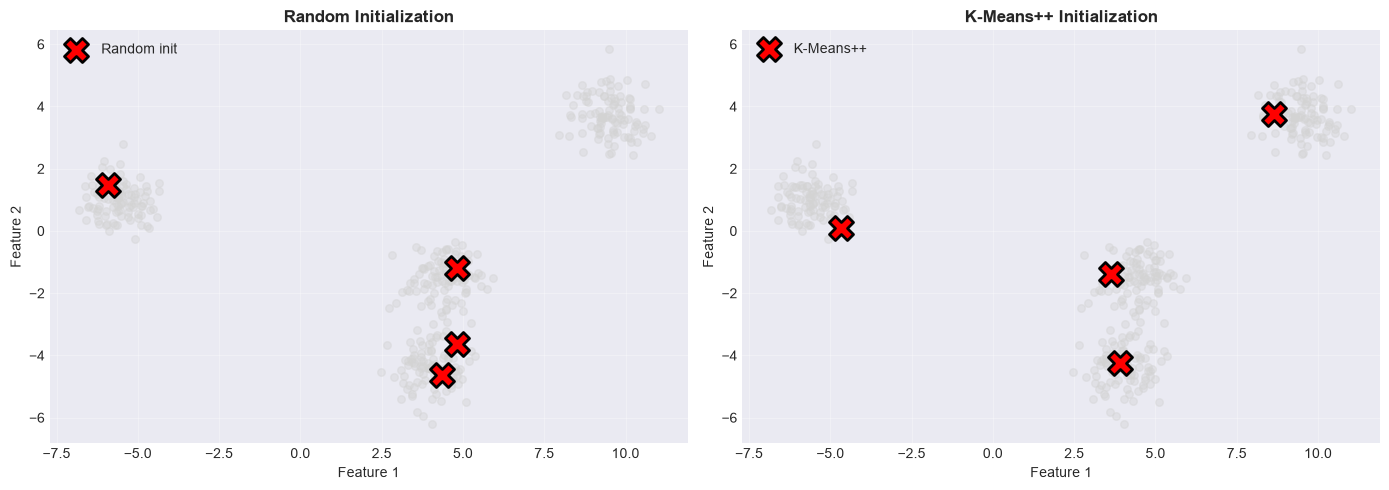

💡 K-Means++ spreads initial centroids across the data space.


In [5]:
def initialize_kmeans_plusplus(X: NDArray, n_clusters: int, random_state: int = None) -> NDArray:
    """
    K-Means++ initialization.
    
    Returns:
        centers: Initial centroid positions (n_clusters, n_features)
    """
    rng = np.random.RandomState(random_state)
    n_samples, n_features = X.shape
    
    # Step 1: Choose first centroid uniformly at random
    first_idx = rng.randint(n_samples)
    centers = [X[first_idx]]
    
    # Step 2: Choose remaining centroids
    for _ in range(n_clusters - 1):
        # Compute distance from each point to nearest chosen centroid
        centers_array = np.array(centers)
        distances = cdist(X, centers_array, metric='euclidean')
        min_distances = np.min(distances, axis=1)
        
        # Choose next centroid with probability proportional to squared distance
        probabilities = min_distances ** 2
        probabilities /= probabilities.sum()
        
        next_idx = rng.choice(n_samples, p=probabilities)
        centers.append(X[next_idx])
    
    return np.array(centers)

# Compare initialization methods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random initialization
ax = axes[0]
random_centers = X_test[np.random.choice(len(X_test), 4, replace=False)]
ax.scatter(X_test[:, 0], X_test[:, 1], c='lightgray', alpha=0.4, s=30)
ax.scatter(random_centers[:, 0], random_centers[:, 1], c='red', marker='X', s=300,
          edgecolors='black', linewidth=2, label='Random init')
ax.set_title('Random Initialization', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)
ax.legend()

# K-Means++ initialization
ax = axes[1]
kpp_centers = initialize_kmeans_plusplus(X_test, 4, random_state=42)
ax.scatter(X_test[:, 0], X_test[:, 1], c='lightgray', alpha=0.4, s=30)
ax.scatter(kpp_centers[:, 0], kpp_centers[:, 1], c='red', marker='X', s=300,
          edgecolors='black', linewidth=2, label='K-Means++')
ax.set_title('K-Means++ Initialization', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print("💡 K-Means++ spreads initial centroids across the data space.")

<a name="convergence-speed"></a>
## Convergence Speed: Random vs. K-Means++

Comparison over 30 runs:

Random initialization:
  Mean inertia: 1051.41
  Std dev:      1816.28
  Min:          286.51
  Max:          8080.06

K-Means++ initialization:
  Mean inertia: 299.87
  Std dev:      71.91
  Min:          286.51
  Max:          687.10

Improvement: K-Means++ finds better solutions more consistently!


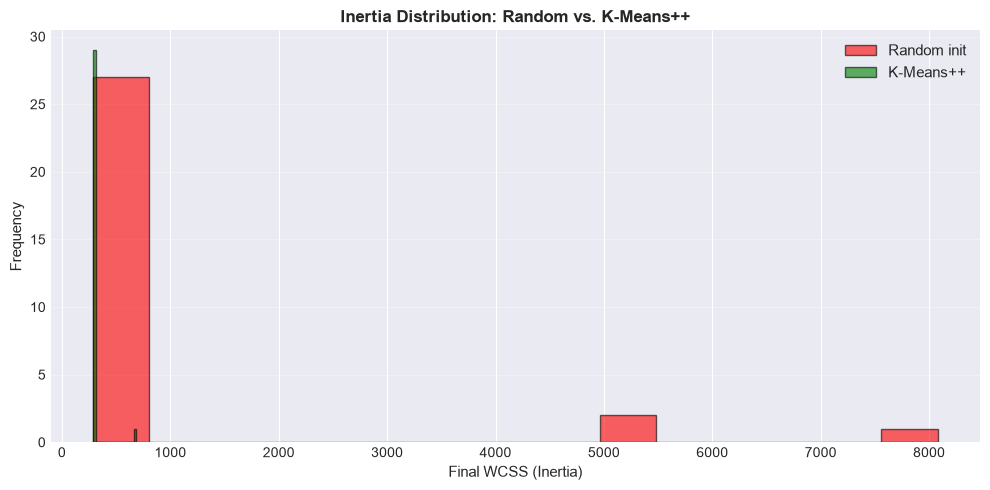

In [6]:
# Compare: Random init vs K-Means++ init
n_trials = 30
results_random = []
results_kpp = []

for seed in range(n_trials):
    # Random initialization
    km_random = SklearnKMeans(n_clusters=4, init='random', random_state=seed, n_init=1)
    km_random.fit(X_test)
    results_random.append(km_random.inertia_)
    
    # K-Means++ initialization
    km_kpp = SklearnKMeans(n_clusters=4, init='k-means++', random_state=seed, n_init=1)
    km_kpp.fit(X_test)
    results_kpp.append(km_kpp.inertia_)

# Statistics
print("Comparison over 30 runs:")
print(f"\nRandom initialization:")
print(f"  Mean inertia: {np.mean(results_random):.2f}")
print(f"  Std dev:      {np.std(results_random):.2f}")
print(f"  Min:          {np.min(results_random):.2f}")
print(f"  Max:          {np.max(results_random):.2f}")

print(f"\nK-Means++ initialization:")
print(f"  Mean inertia: {np.mean(results_kpp):.2f}")
print(f"  Std dev:      {np.std(results_kpp):.2f}")
print(f"  Min:          {np.min(results_kpp):.2f}")
print(f"  Max:          {np.max(results_kpp):.2f}")

print(f"\nImprovement: K-Means++ finds better solutions more consistently!")

# Visualize distributions
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(results_random, bins=15, alpha=0.6, label='Random init', color='red', edgecolor='black')
ax.hist(results_kpp, bins=15, alpha=0.6, label='K-Means++', color='green', edgecolor='black')

ax.set_xlabel('Final WCSS (Inertia)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Inertia Distribution: Random vs. K-Means++', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

<a name="convergence"></a>
## Convergence Analysis

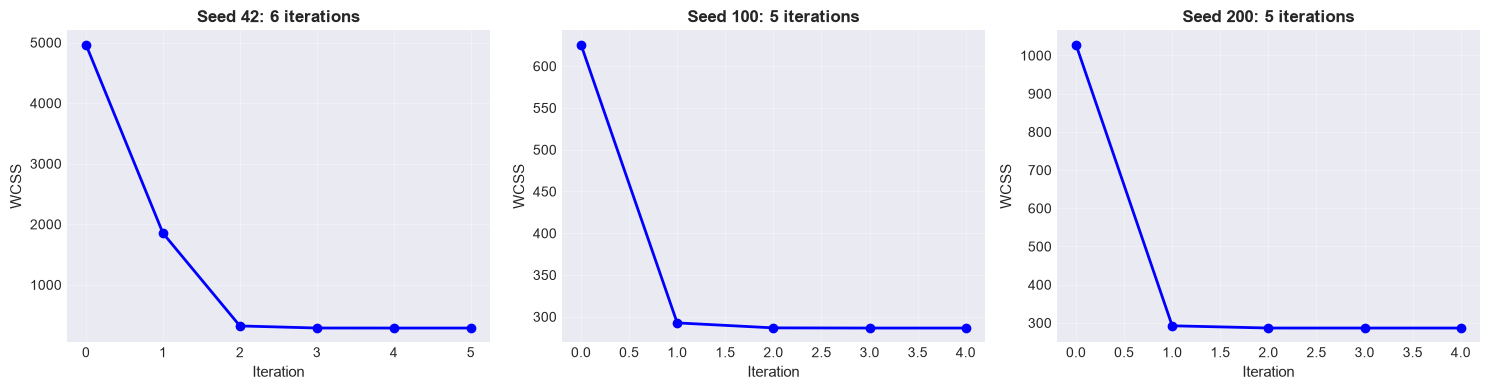

💡 WCSS monotonically decreases (or stays same) at each iteration.
Most improvement occurs in first few iterations.


In [7]:
# Visualize WCSS decrease over iterations
class KMeansTracker(KMeansFromScratch):
    """K-Means variant that tracks iterations."""
    pass

# Run with multiple initializations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, seed in enumerate([42, 100, 200]):
    km = KMeansTracker(n_clusters=4, max_iters=50, random_state=seed)
    km.fit(X_test)
    
    ax = axes[idx]
    ax.plot(range(len(km.inertias_history_)), km.inertias_history_, 'b-', linewidth=2, marker='o')
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel('WCSS', fontsize=11)
    ax.set_title(f'Seed {seed}: {km.n_iter_} iterations', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 WCSS monotonically decreases (or stays same) at each iteration.")
print("Most improvement occurs in first few iterations.")

<a name="visualization"></a>
## Visualizing Lloyd's Algorithm

Let's watch Lloyd's algorithm in action step-by-step.

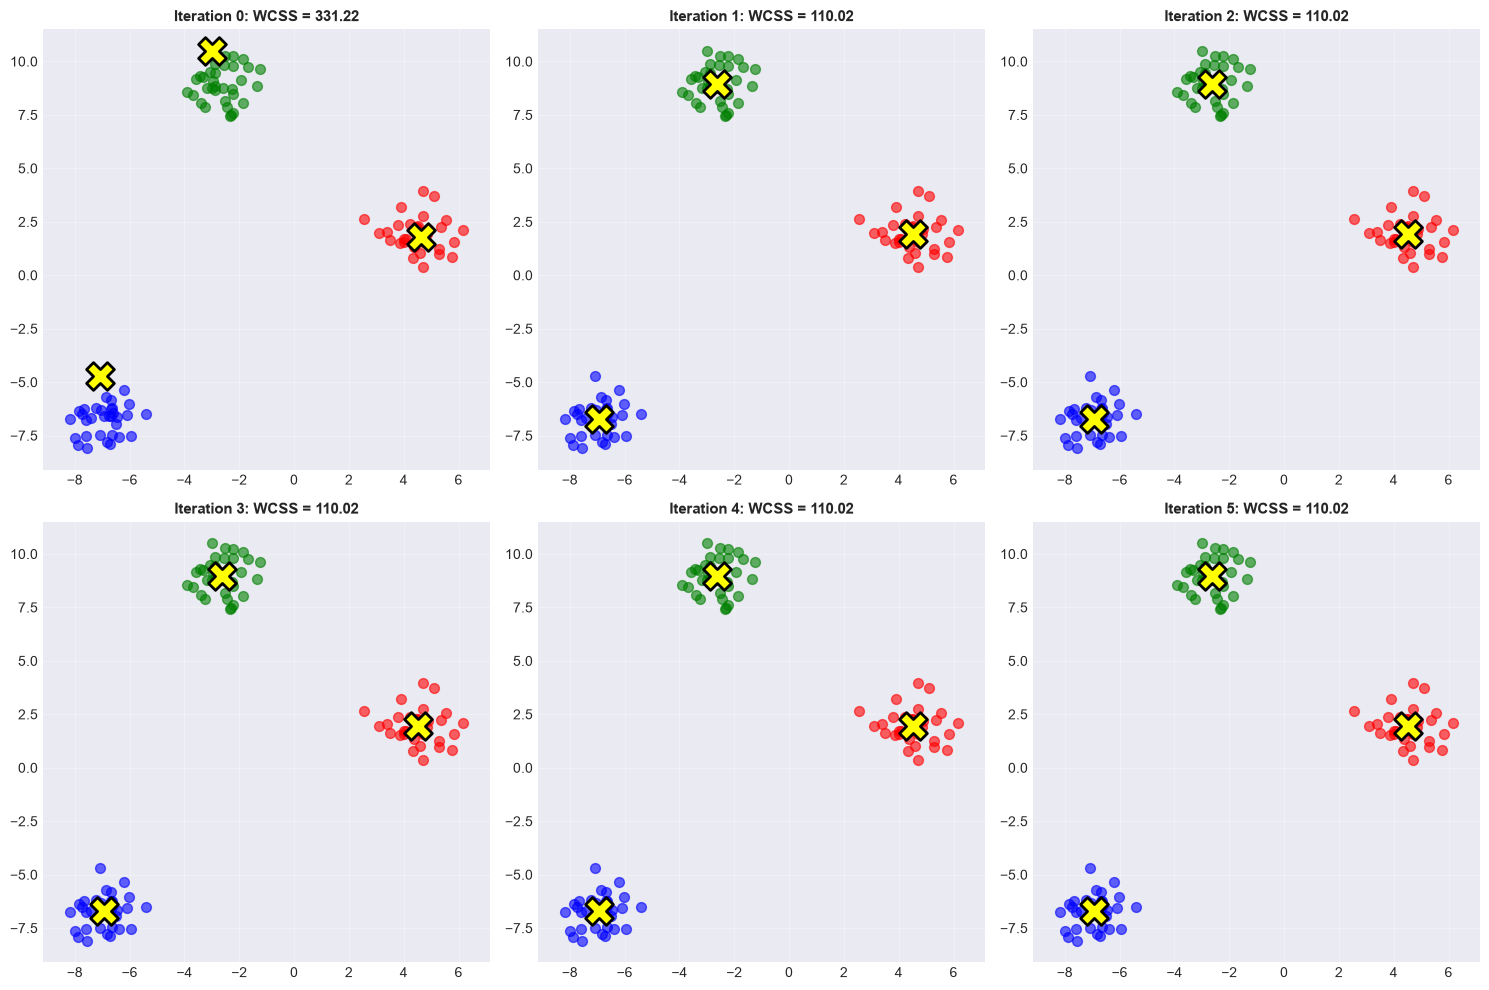

👁️  Watch how centroids move and clusters refine over iterations!


In [8]:
# Simple 2D dataset for visualization
X_simple, _ = make_blobs(n_samples=100, centers=3, n_features=2, cluster_std=0.8, random_state=42)

# Manually run a few iterations and visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Initialize with K-Means++
rng = np.random.RandomState(42)
first_idx = rng.randint(len(X_simple))
centers = [X_simple[first_idx]]

for i in range(2):
    centers_array = np.array(centers)
    distances = cdist(X_simple, centers_array, metric='euclidean')
    min_distances = np.min(distances, axis=1)
    probs = (min_distances ** 2)
    probs /= probs.sum()
    next_idx = rng.choice(len(X_simple), p=probs)
    centers.append(X_simple[next_idx])

centers = np.array(centers)

# Visualize iterations
for iteration in range(6):
    ax = axes[iteration]
    
    # Assign points to clusters
    distances = cdist(X_simple, centers, metric='euclidean')
    labels = np.argmin(distances, axis=1)
    
    # Plot points colored by cluster
    colors = ['red', 'green', 'blue']
    for k in range(len(centers)):
        mask = labels == k
        ax.scatter(X_simple[mask, 0], X_simple[mask, 1], c=colors[k], alpha=0.6, s=50)
    
    # Plot centroids
    ax.scatter(centers[:, 0], centers[:, 1], c='yellow', marker='X', s=400,
              edgecolors='black', linewidth=2)
    
    # Compute WCSS
    wcss = 0
    for k in range(len(centers)):
        mask = labels == k
        wcss += np.sum((X_simple[mask] - centers[k]) ** 2)
    
    ax.set_title(f'Iteration {iteration}: WCSS = {wcss:.2f}', fontsize=11, fontweight='bold')
    ax.set_xlim(X_simple[:, 0].min() - 1, X_simple[:, 0].max() + 1)
    ax.set_ylim(X_simple[:, 1].min() - 1, X_simple[:, 1].max() + 1)
    ax.grid(True, alpha=0.3)
    
    # Update centers (M-step)
    if iteration < 5:
        for k in range(len(centers)):
            mask = labels == k
            if np.sum(mask) > 0:
                centers[k] = X_simple[mask].mean(axis=0)

plt.tight_layout()
plt.show()

print("👁️  Watch how centroids move and clusters refine over iterations!")

<a name="practical"></a>
## Practical Considerations

### 1. The n_init Parameter

Since K-Means finds local optima, scikit-learn runs the algorithm multiple times with different initializations and returns the best result. The `n_init` parameter controls how many times to run:

```python
kmeans = KMeans(n_clusters=3, n_init=10)  # Run 10 times, keep best
```

### 2. Choosing K

We studied internal metrics in Lesson 0B. Use them to choose K:
- Silhouette score
- Davies-Bouldin index
- Elbow method
- Gap statistic

### 3. Scalability

K-Means is **O(n · K · d · i)** where:
- $n$ = number of samples
- $K$ = number of clusters
- $d$ = number of features
- $i$ = number of iterations

For very large datasets, use **Mini-Batch K-Means** (which updates centroids on random subsets).

### 4. Convergence Criterion

K-Means may take many iterations to converge. Practical stopping criteria:
- Change in WCSS is very small (we used `tol=1e-4`)
- Maximum iterations reached
- Centroids don't move

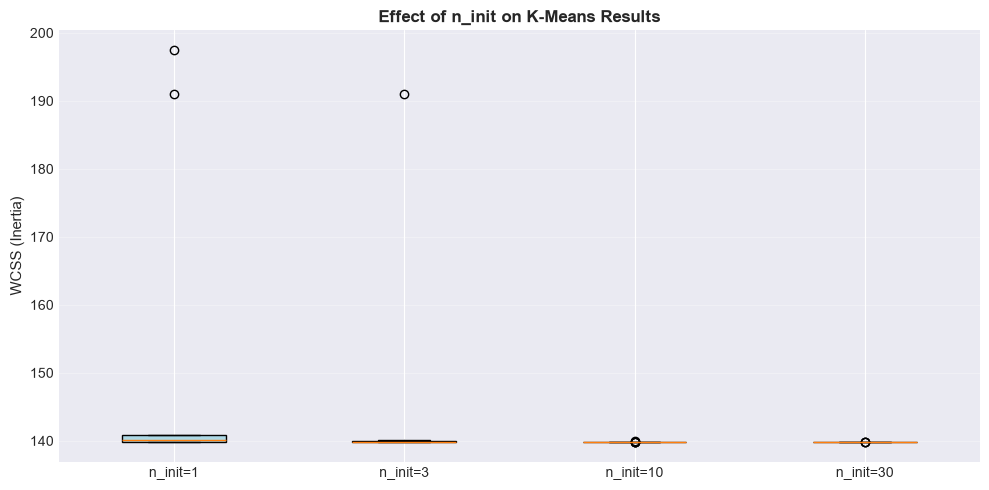

💡 Insight:
  n_init= 1: best inertia = 139.82
  n_init= 3: best inertia = 139.82
  n_init=10: best inertia = 139.82
  n_init=30: best inertia = 139.82

Higher n_init reduces risk of poor local optima.


In [9]:
# Demo: Practical K-Means usage on Iris
iris = load_iris()
X_iris = iris.data
scaler = StandardScaler()
X_iris = scaler.fit_transform(X_iris)

# Run K-Means with different n_init values
fig, ax = plt.subplots(figsize=(10, 5))

n_init_values = [1, 3, 10, 30]
inertias = []
best_inertias = []

for n_init in n_init_values:
    all_inertias = []
    for _ in range(20):  # Run 20 times to see variation
        km = SklearnKMeans(n_clusters=3, n_init=n_init)
        km.fit(X_iris)
        all_inertias.append(km.inertia_)
    
    inertias.append(all_inertias)
    best_inertias.append(min(all_inertias))

# Box plot
bp = ax.boxplot(inertias, tick_labels=[f'n_init={n}' for n in n_init_values], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')

ax.set_ylabel('WCSS (Inertia)', fontsize=11)
ax.set_title('Effect of n_init on K-Means Results', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("💡 Insight:")
for n_init, best in zip(n_init_values, best_inertias):
    print(f"  n_init={n_init:2d}: best inertia = {best:.2f}")
print("\nHigher n_init reduces risk of poor local optima.")

<a name="soft-kmeans"></a>
## Soft K-Means and the Probabilistic View

### From Hard Assignment to Responsibilities

Lloyd's algorithm makes a **hard** assignment: each point belongs entirely to
its nearest centroid. Soft K-means relaxes this into a **responsibility**
$r_{ik} \in [0, 1]$ — how much point $i$ "belongs" to cluster $k$ — via a
softmax over negative squared distances, scaled by an inverse-temperature
$\beta > 0$:

$$r_{ik} = \frac{\exp(-\beta \, \|x_i - \mu_k\|^2)}{\sum_{j=1}^{K} \exp(-\beta \, \|x_i - \mu_j\|^2)}$$

Two limits are informative:
- As $\beta \to \infty$: the softmax sharpens into a one-hot vector — soft
  K-means **recovers hard K-means** exactly (the nearest centroid gets
  responsibility 1, all others 0).
- As $\beta \to 0$: all clusters get equal responsibility $1/K$ regardless
  of distance — assignments become uninformative.

This is not a new algorithm bolted onto K-means — it is **exactly the E-step
of a Gaussian Mixture Model** with $K$ equal-weight, spherical, fixed-variance
Gaussians ($\sigma^2 = 1/(2\beta)$ for every cluster). Lesson 4 (GMM) lifts
the fixed-$\beta$, fixed-shape restriction and *learns* each cluster's
variance and mixing weight from data — soft K-means is GMM's most constrained
special case, not a different family of methods.


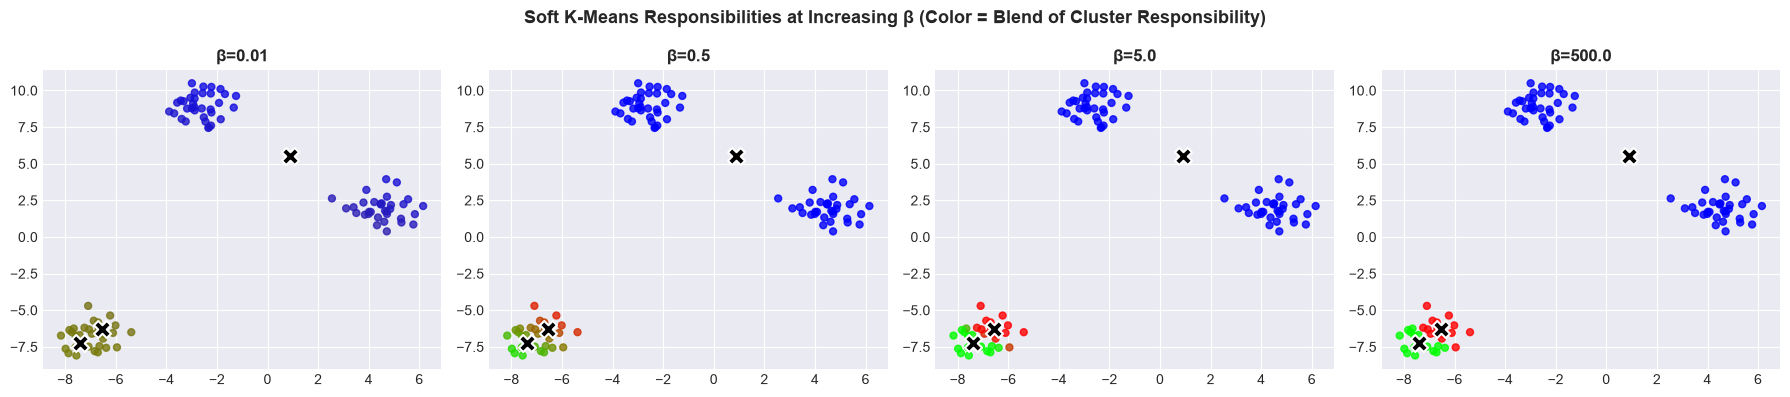

β=  0.01: mean max-responsibility=0.691, agreement with hard K-means=1.000
β=   0.5: mean max-responsibility=0.895, agreement with hard K-means=1.000
β=   5.0: mean max-responsibility=0.990, agreement with hard K-means=1.000
β= 500.0: mean max-responsibility=1.000, agreement with hard K-means=1.000


In [10]:
def soft_assign(X: NDArray, centroids: NDArray, beta: float) -> NDArray:
    """
    Compute soft responsibilities r_ik = softmax_k(-beta * ||x_i - mu_k||^2).
    Returns an (n_samples, n_clusters) matrix where each row sums to 1.
    """
    sq_dists = np.sum((X[:, None, :] - centroids[None, :, :]) ** 2, axis=2)
    logits = -beta * sq_dists
    logits -= logits.max(axis=1, keepdims=True)  # numerical stability
    exp_logits = np.exp(logits)
    return exp_logits / exp_logits.sum(axis=1, keepdims=True)

# Use the converged hard K-means centroids from X_simple as a fixed reference point
hard_km = KMeansFromScratch(n_clusters=3, random_state=42)
hard_km.fit(X_simple)

betas = [0.01, 0.5, 5.0, 500.0]
fig, axes = plt.subplots(1, len(betas), figsize=(18, 4))

for ax, beta in zip(axes, betas):
    resp = soft_assign(X_simple, hard_km.cluster_centers_, beta)
    hard_labels = resp.argmax(axis=1)
    # Color by a blend of cluster colors weighted by responsibility
    scatter_colors = resp @ np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
    ax.scatter(X_simple[:, 0], X_simple[:, 1], c=scatter_colors, s=25, alpha=0.8)
    ax.scatter(hard_km.cluster_centers_[:, 0], hard_km.cluster_centers_[:, 1],
               c='black', marker='X', s=150, edgecolors='white', linewidths=1.5)
    ax.set_title(f'β={beta}', fontsize=12, fontweight='bold')

plt.suptitle('Soft K-Means Responsibilities at Increasing β (Color = Blend of Cluster Responsibility)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Quantify the hard-assignment limit: agreement with true hard K-means as beta grows
for beta in betas:
    resp = soft_assign(X_simple, hard_km.cluster_centers_, beta)
    soft_labels = resp.argmax(axis=1)
    agreement = np.mean(soft_labels == hard_km.labels_)
    max_responsibility = resp.max(axis=1).mean()
    print(f"β={beta:>6}: mean max-responsibility={max_responsibility:.3f}, "
          f"agreement with hard K-means={agreement:.3f}")


<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **K-Means solves a well-defined optimization problem**: Minimize within-cluster sum of squares (WCSS)

2. **Lloyd's algorithm efficiently finds a local optimum**:
   - E-step: Assign each point to nearest centroid
   - M-step: Recompute centroids as cluster means
   - WCSS monotonically decreases

3. **Initialization matters heavily**:
   - Random initialization can lead to poor local optima
   - K-Means++ spreads initial centroids and finds better solutions more reliably

4. **Practical usage**:
   - Use `n_init` to run multiple times and keep the best result
   - Choose K using silhouette, Davies-Bouldin, elbow, or gap statistic
   - Mini-Batch K-Means for scalability

5. **Limitations**:
   - Only finds local optima (global optimization is NP-hard)
   - Assumes clusters are roughly spherical and similar size
   - Sensitive to outliers (distances are squared)
   - Can create empty clusters

### Next Steps

In Lesson 1B (practical), we'll:
- Use scikit-learn's `KMeans` with advanced features
- Explore `MiniBatchKMeans` for large datasets
- Apply K-Means to real image compression and customer segmentation problems
- Compare runtime and quality vs. other clustering methods

Then we'll move on to more sophisticated algorithms:
- Hierarchical clustering (preserves structure without fixing K)
- DBSCAN (finds arbitrary shapes)
- Gaussian Mixture Models (soft, probabilistic assignments)

Remember: **K-Means is simple, fast, and often the best first clustering algorithm to try.**